# Question 3: Dimensionality Reduction and Visualisation



## Objective
To apply PCA and t-SNE for feature reduction and analyze their impact on visualization and classification performance.

## Dataset
The MNIST dataset is used, which consists of handwritten digit images (0–9).

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

X.shape

(70000, 784)

In [ ]:
X_small = X[:5000]
y_small = y[:5000]

## PCA

PCA reduces dimensionality by projecting the data onto directions of maximum variance. The first few principal components capture most of the information in the dataset.

In [ ]:
from sklearn.decomposition import PCA

# 2D için
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_small)

# 50D için
pca_50 = PCA(n_components=50)
X_pca_50 = pca_50.fit_transform(X_small)

In [ ]:
pca_full = PCA()
pca_full.fit(X_small)

explained_variance = pca_full.explained_variance_ratio_[:10]

print(explained_variance)

[0.09867566 0.07404546 0.06127705 0.05405319 0.04737567 0.04419003
 0.03370101 0.02912435 0.0277273  0.02330222]


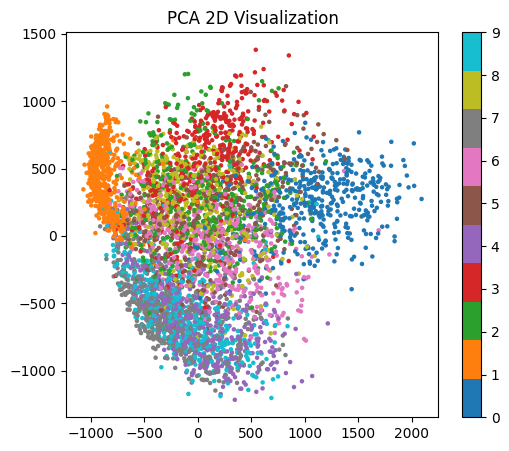

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=y_small, cmap='tab10', s=5)
plt.colorbar()
plt.title("PCA 2D Visualization")
plt.show()

### PCA Visualization

The PCA 2D visualization shows that some digit classes form loose clusters, but there is significant overlap between many classes.

This indicates that PCA captures global variance but does not clearly separate different digit classes in low dimensions.

In [ ]:
from sklearn.manifold import TSNE

tsne_30 = TSNE(n_components=2, perplexity=30, random_state=123)
X_tsne_30 = tsne_30.fit_transform(X_small)

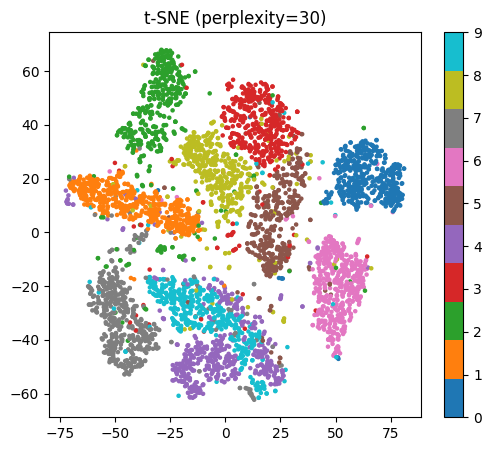

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X_tsne_30[:,0], X_tsne_30[:,1], c=y_small, cmap='tab10', s=5)
plt.colorbar()
plt.title("t-SNE (perplexity=30)")
plt.show()

### t-SNE Visualization

The t-SNE visualization shows clear and well-separated clusters for different digit classes. Unlike PCA, which produced overlapping groups, t-SNE effectively captures the local structure of the data.

This demonstrates that t-SNE is highly effective for visualizing high-dimensional data in lower dimensions.

In [ ]:
tsne_50 = TSNE(n_components=2, perplexity=50, random_state=123)
X_tsne_50 = tsne_50.fit_transform(X_small)

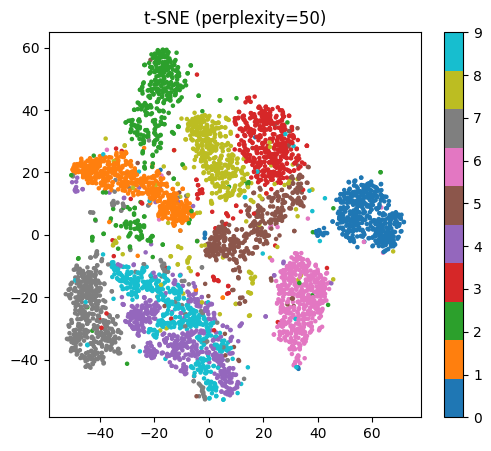

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X_tsne_50[:,0], X_tsne_50[:,1], c=y_small, cmap='tab10', s=5)
plt.colorbar()
plt.title("t-SNE (perplexity=50)")
plt.show()

### Effect of Perplexity in t-SNE

The t-SNE visualization with perplexity=30 shows more compact and well-separated clusters compared to perplexity=50.

With higher perplexity, the clusters become more spread out and some class boundaries become less distinct. This is because higher perplexity considers a broader neighborhood, capturing more global structure at the expense of local detail.

Therefore, perplexity=30 provides a clearer separation of digit classes in this case.

## k-NN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors=5)

# Original (784)
acc_original = cross_val_score(knn, X_small, y_small, cv=5).mean()

# PCA 50
acc_pca = cross_val_score(knn, X_pca_50, y_small, cv=5).mean()

# t-SNE (2D)
acc_tsne = cross_val_score(knn, X_tsne_30, y_small, cv=5).mean()

print("Original:", acc_original)
print("PCA 50:", acc_pca)
print("t-SNE:", acc_tsne)

Original: 0.9276
PCA 50: 0.9418
t-SNE: 0.9296


## Conclusion

PCA created overlapping clusters in 2D space while maintaining the dataset's overall variance. On the other hand, distinct digit classes were easily distinguished by the well-separated clusters produced by t-SNE.
PCA with 50 dimensions outperformed both the original dataset and the t-SNE representation in terms of accuracy when utilizing k-NN classification.

PCA effectively reduces dimensionality while maintaining global structure, so it is applicable for  downstream tasks such as classification. It may not be able to capture complex non-linear interactions, though.
Conversely, t-SNE is very useful for visualization since it shows distinct clusters and captures local features. However, because it affects global distances, it is not acceptable for classification tasks.
In general, t-SNE is more appropriate for visualization, whereas PCA is more compatible with machine learning processes.